<a href="https://colab.research.google.com/github/JosephHall978/JPEGShields/blob/main/jpegshield_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip uninstall -y sympy
!pip install sympy~=1.13.3
!pip -q install opencv-python scikit-image scipy pandas tqdm matplotlib
#!pip install compressai
!pip install pillow-jxl
!pip install ultralytics
!pip install "git+https://github.com/JPEG-Trust-Community/watermarking.git#subdirectory=evaluation_metric/package"

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 69.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pillow-jxl (from versions: none)
ERROR: No matching distribution found for pillow-jxl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.7 MB/s eta 0:00:00
  Cloning https://github.com/JPEG-Trust-Community/watermarking.git to /tmp/pip-req-build-ac8uly3a
  Running command git clone --filter=blob:none --quiet https://github.com/JPEG-Trust-Community/watermarking.git /tmp/pip-req-build-ac8uly3a
  Resolved https://github.com/JPEG-Trust-Community/watermarking.git to commit f93ed7bd2f73a080bdba30167abc00e4e2a1a5ed
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [3]:
# Replace with the URL of your GitHub repository
github_repo_url = "https://github.com/JosephHall978/JPEGShields.git"

# Clone the repository
!git clone {github_repo_url}

Cloning into 'JPEGShields'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 40 (delta 16), reused 19 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 3.37 MiB | 8.47 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

DATASET_ROOT = "/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public"
WATERMARKER_PATH = "/content/JPEGShields/WaterMarker.py"
OUTPUT_ROOT = "/content/drive/MyDrive/JPEGShields-main/outputs"

SUBFOLDERS_TO_INCLUDE = ["Camera_Capture", "Synthetic"]
WATERMARK_LENGTH = 100
RANDOM_SEED = 42
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT}")

if not os.path.exists(WATERMARKER_PATH):
    raise FileNotFoundError(f"WaterMarker.py not found: {WATERMARKER_PATH}")

watermarker_dir = os.path.dirname(WATERMARKER_PATH)
if watermarker_dir not in sys.path:
    sys.path.append(watermarker_dir)

print("Dataset root:", DATASET_ROOT)
print("WaterMarker path:", WATERMARKER_PATH)
print("Dataset contents:", os.listdir(DATASET_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root: /content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public
WaterMarker path: /content/JPEGShields/WaterMarker.py
Dataset contents: ['Synthetic', 'Camera_Capture']


In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from WaterMarker import WaterMarker

In [7]:
def list_images_recursive(folder_paths, extensions=IMAGE_EXTENSIONS):
    items = []
    for folder in folder_paths:
        for current_root, dirs, files in os.walk(folder):
            for f in files:
                ext = os.path.splitext(f)[1].lower()
                if ext in extensions:
                    items.append(os.path.join(current_root, f))
    return sorted(items)

def safe_relpath(path, root):
    try:
        return os.path.relpath(path, root)
    except Exception:
        return os.path.basename(path)

def read_image_rgb(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Failed to read image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def save_image_rgb(path, img_rgb):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    ok = cv2.imwrite(path, img_bgr)
    if not ok:
        raise IOError(f"Failed to save image: {path}")

def ber_from_arrays(a, b):
    a = np.asarray(a).astype(np.uint8).flatten()
    b = np.asarray(b).astype(np.uint8).flatten()
    if len(a) != len(b):
        raise ValueError(f"BER arrays have different lengths: {len(a)} vs {len(b)}")
    return float(np.mean(a != b))

In [8]:
input_dirs = []
for sub in SUBFOLDERS_TO_INCLUDE:
    p = os.path.join(DATASET_ROOT, sub)
    if os.path.exists(p):
        input_dirs.append(p)

if not input_dirs:
    input_dirs = [DATASET_ROOT]

print("Input directories:")
for d in input_dirs:
    print(" -", d)

os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, "watermarked"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, "processed"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, "watermarks"), exist_ok=True)

image_paths = list_images_recursive(input_dirs)

print(f"\nFound {len(image_paths)} images.")
for p in image_paths[:10]:
    print(p)

if len(image_paths) == 0:
    raise RuntimeError("No images found. Check DATASET_ROOT and the folder structure.")

Input directories:
 - /content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture
 - /content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Synthetic

Found 200 images.
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R001.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R002.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R003.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R004.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R005.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_Capture/ICIP_GC1_JPT_WM_R006.png
/content/drive/MyDrive/JPEGShields-main/Watermark Evaluation Dataset-Public/Camera_

In [9]:
rng = np.random.default_rng(RANDOM_SEED)
original_watermark = rng.integers(0, 2, size=WATERMARK_LENGTH, dtype=np.uint8)

marker = WaterMarker()

print("Watermarker instance created.")
print("Watermark length:", len(original_watermark))
print("First 20 bits:", original_watermark[:20].tolist())

Watermarker instance created.
Watermark length: 100
First 20 bits: [1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0]


In [ ]:
import tempfile
import traceback
import watermarkbench as wb
import numpy as np

results = []
from google.colab import userdata
key = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = key

ATTACK_FN_MAP = {
    "rotate":           lambda path: wb.attack.rotate(path,15),
    "resized":          lambda path: wb.attack.resized(path,80),
    "crop":             lambda path: wb.attack.crop(path,80),
    "scaled":           lambda path: wb.attack.scaled(path,1.2),
    "flipping":         lambda path: wb.attack.flipping(path,"H"),
    "jpeg":             lambda path: wb.attack.jpeg(path,75),
    "jpeg2000":         lambda path: wb.attack.jpeg2000(path,75),
    "jpegai":           lambda path: wb.attack.jpegai(path,4),
    "jpegxl":           lambda path: wb.attack.jpegxl(path,50),
    #"jpegxs":           lambda path: wb.attack.jpegxs_compression(path,70),
    "gaussian_noise":   lambda path: wb.attack.gaussian_noise(path,0.01),
    "gamma_correct":    lambda path: wb.attack.gamma_correction(path,1.5),
    "histogram_equalize": lambda path: wb.attack.histogram_equalization(path, 0.2),
    "speckle_noise":    lambda path: wb.attack.speckle_noise(path,0.3),
    "blurring":         lambda path: wb.attack.blurring(path,5),
    "brightness":       lambda path: wb.attack.brightness(path,1.3),
    "sharpness":        lambda path: wb.attack.sharpness(path,1.25),
    "median_filtering": lambda path: wb.attack.median_filtering(path,5),
    "create_ai":        lambda path: wb.attack.create_ai(path),
    "replace_ai":       lambda path: wb.attack.replace_ai(path),
    "remove_ai":        lambda path: wb.attack.remove_ai(path),
    "none":             lambda path: path,
}

for attack in ATTACK_FN_MAP.keys():
    attack_fn    = ATTACK_FN_MAP[attack]
    process_name = attack

    fid_orig_imgs = []
    fid_wm_imgs   = []

    attack_results = []

    for img_path in tqdm(image_paths, desc=f"Processing images\t|\t{process_name}"):
        tmp_watermarked = None
        attacked_path   = None
        try:
            rel  = safe_relpath(img_path, DATASET_ROOT)
            stem = os.path.splitext(rel)[0]

            original_img = read_image_rgb(img_path)

            # 1. Watermark image
            watermarked_img = marker.generate(original_img, original_watermark)

            # 2. Evaluate per-image quality metrics (no FID yet)
            metrics = marker.evaluate_watermarking(original_img, watermarked_img)

            # 3. Save watermarked image to a temp file so wb.attack can read it
            with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
                tmp_watermarked = f.name
            save_image_rgb(tmp_watermarked, watermarked_img)

            if process_name != "none":
                # 4. Apply attack — returns path to attacked output file
                attacked_path = attack_fn(tmp_watermarked)
                processed_img = read_image_rgb(attacked_path)
            else:
                processed_img = read_image_rgb(tmp_watermarked)

            # 5. Extract watermark from processed image
            recovered_watermark = marker.recover(processed_img)

            # 6. Compute BER
            ber = ber_from_arrays(original_watermark, recovered_watermark)

            # 7. Save final outputs
            watermarked_out = os.path.join(OUTPUT_ROOT, "watermarked", stem + "_watermarked.png")
            processed_out   = os.path.join(OUTPUT_ROOT, "processed",   stem + f"_processed_{process_name}.png")
            gt_bits_out     = os.path.join(OUTPUT_ROOT, "watermarks",  stem + "_watermark_gt.txt")
            rec_bits_out    = os.path.join(OUTPUT_ROOT, "watermarks",  stem + "_watermark_recovered.txt")

            save_image_rgb(watermarked_out, watermarked_img)
            save_image_rgb(processed_out, processed_img)

            os.makedirs(os.path.dirname(gt_bits_out), exist_ok=True)
            with open(gt_bits_out, "w") as f:
                f.write("".join(map(str, original_watermark.tolist())))
            with open(rec_bits_out, "w") as f:
                f.write("".join(map(str, recovered_watermark.astype(int).tolist())))

            fid_orig_imgs.append(original_img)
            fid_wm_imgs.append(watermarked_img)

            attack_results.append({
                "image_path":             img_path,
                "relative_path":          rel,
                "process_name":           process_name,
                "process_param":          -1,
                "PSNR":                   float(metrics["PSNR"]),
                "wPSNR":                  float(metrics["wPSNR"]),
                "SSIM":                   float(metrics["SSIM"]),
                "JND":                    float(metrics["JND"]),
                "FID":                    None,   # back-filled below
                "BER":                    ber,
                "watermarked_output_path": watermarked_out,
                "processed_output_path":   processed_out,
                "gt_bits_path":            gt_bits_out,
                "recovered_bits_path":     rec_bits_out,
                "error":                   None,
            })

        except Exception as e:
            print(traceback.format_exc())
            attack_results.append({
                "image_path":             img_path,
                "relative_path":          safe_relpath(img_path, DATASET_ROOT),
                "process_name":           process_name,
                "process_param":          -1,
                "PSNR": None, "wPSNR": None, "SSIM": None, "JND": None, "FID": None, "BER": None,
                "watermarked_output_path": None, "processed_output_path": None,
                "gt_bits_path":            None, "recovered_bits_path":   None,
                "error":                   str(e),
            })
            break

        finally:
            if tmp_watermarked and os.path.exists(tmp_watermarked):
                os.remove(tmp_watermarked)
            if attacked_path and os.path.exists(attacked_path):
                os.remove(attacked_path)

    attack_fid = None
    if fid_orig_imgs:
        try:
            attack_fid = marker.compute_fid(fid_orig_imgs, fid_wm_imgs)
            print(f"[{process_name}] FID = {attack_fid:.4f}  (n={len(fid_orig_imgs)} images)")
        except Exception as fid_err:
            print(f"[{process_name}] FID computation failed: {fid_err}")

    for row in attack_results:
        if row["error"] is None:
            row["FID"] = attack_fid

    results.extend(attack_results)


results_df = pd.DataFrame(results)
csv_path = os.path.join(OUTPUT_ROOT, "jpegshield_pipeline_results.csv")
results_df.to_csv(csv_path, index=False)

print(f"Done. Results saved to: {csv_path}")
results_df.head()

Processing images	|	rotate:   0%|          | 0/200 [00:00<?, ?it/s]

[rotate] FID = 3.3899  (n=200 images)


Processing images	|	resized:   0%|          | 0/200 [00:00<?, ?it/s]

[resized] FID = 3.3899  (n=200 images)


Processing images	|	crop:   0%|          | 0/200 [00:00<?, ?it/s]

...

Processing images	|	remove_ai:   0%|          | 0/200 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/tmp/ipykernel_2110/3000087415.py", line 67, in <cell line: 0>
    attacked_path = attack_fn(tmp_watermarked)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2110/3000087415.py", line 32, in <lambda>
    "remove_ai":        lambda path: wb.attack.remove_ai(path),
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/watermarkbench/attack/__init__.py", line 40, in _call_ai
    y = core_fn(x_chw_u8, None, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/watermarkbench/attack/_core.py", line 936, in remove_ai
    mask_l = _make_primary_mask_yolo_sam(image, threshold_area=threshold_area)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/watermarkbench/attack/_core.py", line 736, in _make_primary_mask_yolo_sam
    yolo, predictor, _ = _get_yolo_

Processing images	|	none:   0%|          | 0/200 [00:00<?, ?it/s]

[none] FID = 3.3899  (n=200 images)
Done. Results saved to: /content/drive/MyDrive/JPEGShields-main/outputs/jpegshield_pipeline_results.csv


,image_path,relative_path,process_name,process_param,PSNR,wPSNR,SSIM,JND,FID,BER,watermarked_output_path,processed_output_path,gt_bits_path,recovered_bits_path,error
0,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R001.png,rotate,-1,46.472340,47.887216,0.998041,0.791533,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,None
1,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R002.png,rotate,-1,45.617768,46.754630,0.992369,0.939796,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,None
2,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R003.png,rotate,-1,44.478940,45.551215,0.997445,1.038100,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,None
3,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R004.png,rotate,-1,49.350191,51.420464,0.997860,0.530721,3.389907,0.50,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,None
4,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R005.png,rotate,-1,49.102889,50.752922,0.998588,0.542183,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,None


In [10]:
csv_path = os.path.join(OUTPUT_ROOT, "jpegshield_pipeline_results.csv")
results_df = pd.read_csv(csv_path)

display(results_df)

valid_df = results_df[results_df["error"].isna()].copy()

print("Total images:", len(results_df))
print("Successful:", len(valid_df))
print("Errors:", int(results_df["error"].notna().sum()))

if len(valid_df) > 0:
    for col in ["PSNR", "wPSNR", "SSIM", "JND", "BER"]:
        if col in valid_df.columns:
            print(f"{col} mean:", float(valid_df[col].dropna().mean()))

,image_path,relative_path,process_name,process_param,PSNR,wPSNR,SSIM,JND,FID,BER,watermarked_output_path,processed_output_path,gt_bits_path,recovered_bits_path,error
0,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R001.png,rotate,-1,46.472340,47.887216,0.998041,0.791533,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
1,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R002.png,rotate,-1,45.617768,46.754630,0.992369,0.939796,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
2,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R003.png,rotate,-1,44.478940,45.551215,0.997445,1.038100,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
3,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R004.png,rotate,-1,49.350191,51.420464,0.997860,0.530721,3.389907,0.50,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
4,/content/drive/MyDrive/JPEGShields-main/Waterm...,Camera_Capture/ICIP_GC1_JPT_WM_R005.png,rotate,-1,49.102889,50.752922,0.998588,0.542183,3.389907,0.51,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3001,/content/drive/MyDrive/JPEGShields-main/Waterm...,Synthetic/ICIP_GC1_JPT_WM_S096.png,none,-1,51.139631,52.691351,0.997696,0.429472,3.389907,0.04,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
3002,/content/drive/MyDrive/JPEGShields-main/Waterm...,Synthetic/ICIP_GC1_JPT_WM_S097.png,none,-1,46.930264,48.647786,0.995099,0.729973,3.389907,0.03,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
3003,/content/drive/MyDrive/JPEGShields-main/Waterm...,Synthetic/ICIP_GC1_JPT_WM_S098.png,none,-1,42.894144,46.208355,0.993754,0.959678,3.389907,0.09,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN
3004,/content/drive/MyDrive/JPEGShields-main/Waterm...,Synthetic/ICIP_GC1_JPT_WM_S099.png,none,-1,38.660793,41.711083,0.970847,1.601756,3.389907,0.03,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,/content/drive/MyDrive/JPEGShields-main/output...,NaN


Total images: 3006
Successful: 3000
Errors: 6
PSNR mean: 45.298999356563996
wPSNR mean: 47.142268647179534
SSIM mean: 0.9934984370893405
JND mean: 0.967134099913185
BER mean: 0.3198766666666667


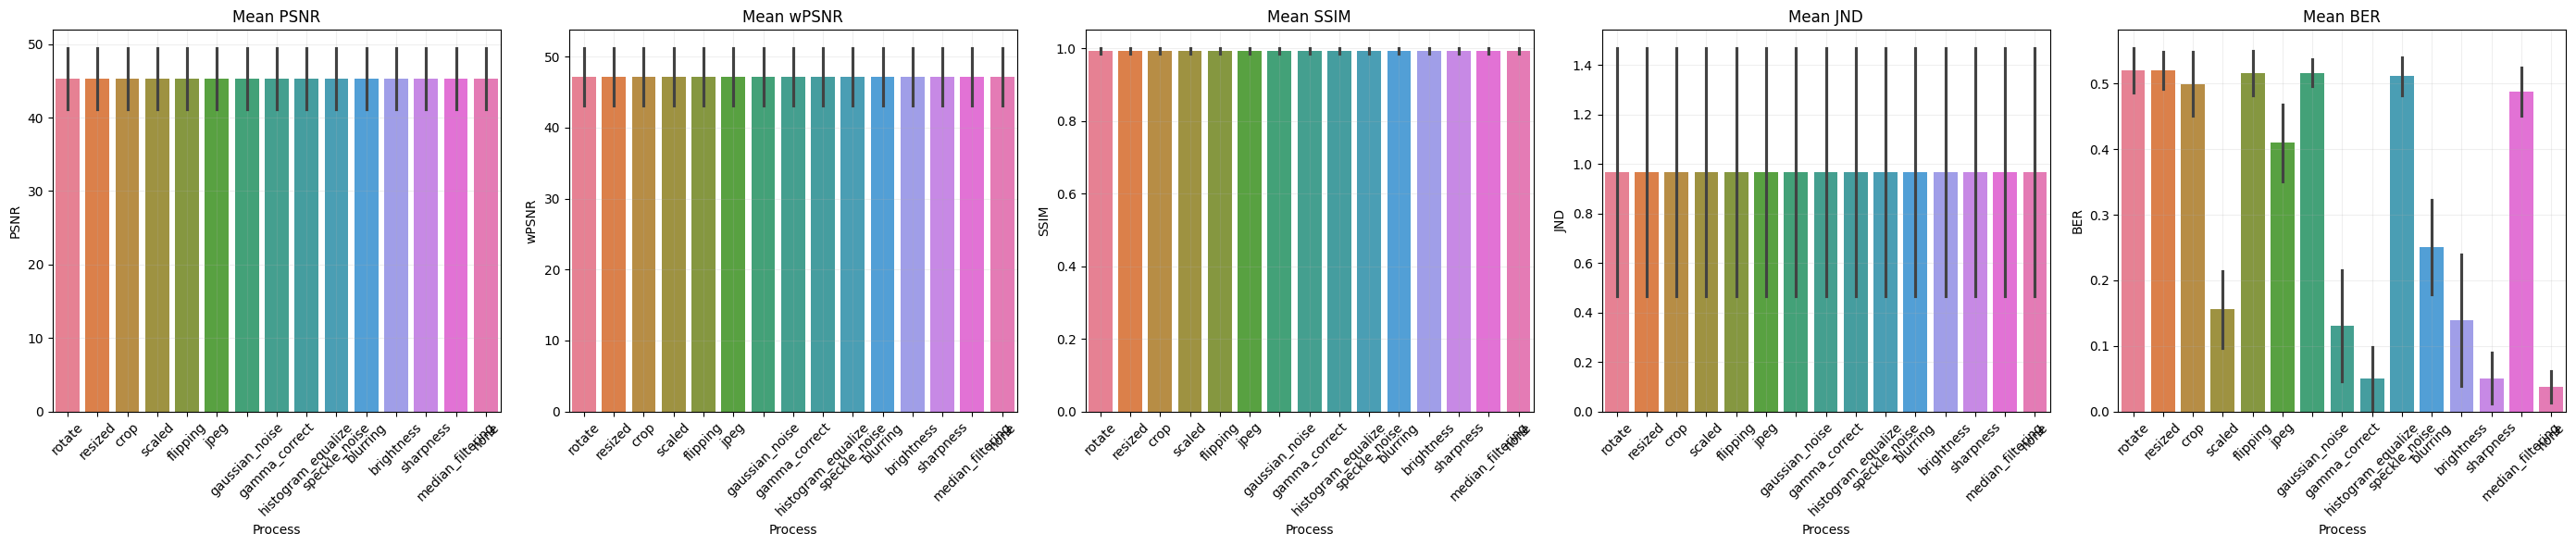

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(figsize=(28, 6), ncols=5)

metrics = ["PSNR", "wPSNR", "SSIM", "JND", "BER"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=valid_df,
        x="process_name",
        y=metric,
        estimator="mean",
        errorbar="sd",   # std dev error bars
        hue="process_name",
        ax=axes[i]
    )
    axes[i].set_title(f"Mean {metric}")
    axes[i].set_xlabel("Process")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

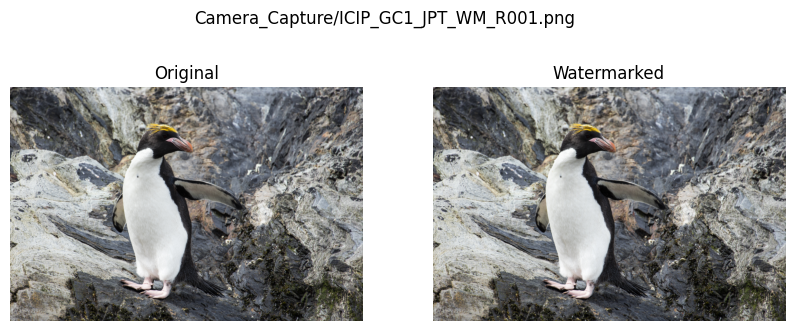

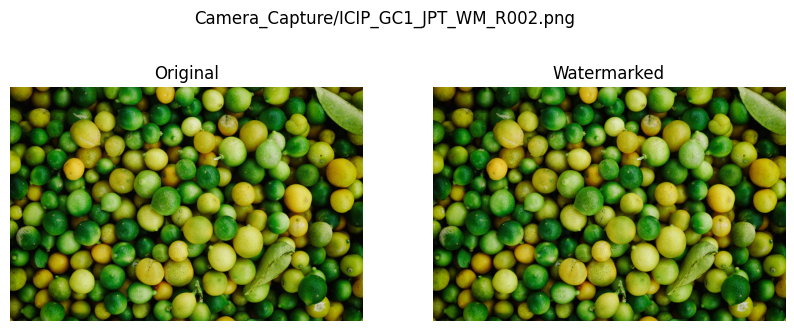

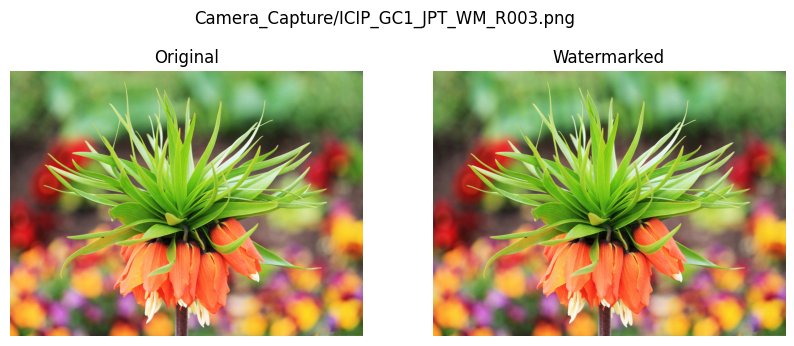

In [12]:
preview_df = results_df[results_df["error"].isna()].head(3)

for _, row in preview_df.iterrows():
    original = read_image_rgb(row["image_path"])
    watermarked = read_image_rgb(row["watermarked_output_path"])

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(watermarked)
    plt.title("Watermarked")
    plt.axis("off")

    plt.suptitle(row["relative_path"])
    plt.show()

In [14]:
import pandas as pd
import numpy as np

metrics = ["PSNR", "wPSNR", "SSIM", "JND", "BER", "FID"]
valid_df["source"] = valid_df["relative_path"].apply(lambda x: os.path.dirname(x))

summary = (
    valid_df.groupby(["source", "process_name"])[metrics]
    .agg(["min", "mean", "std", "max"])
)

final_table = pd.DataFrame()

for metric in metrics:
    m = summary[metric]["mean"]
    s = summary[metric]["std"]

    final_table[(metric, "min")] = summary[metric]["min"]
    final_table[(metric, "mean")] = m
    final_table[(metric, "max")] = summary[metric]["max"]

final_table = final_table.round(4)
final_table = final_table.reset_index()
final_table.to_csv("/content/drive/MyDrive/JPEGShields-main/outputs/jpegshield_pipeline_results_summary.csv")

final_table

,source,process_name,"(PSNR, min)","(PSNR, mean)","(PSNR, max)","(wPSNR, min)","(wPSNR, mean)","(wPSNR, max)","(SSIM, min)","(SSIM, mean)","(SSIM, max)","(JND, min)","(JND, mean)","(JND, max)","(BER, min)","(BER, mean)","(BER, max)","(FID, min)","(FID, mean)","(FID, max)"
0,Camera_Capture,blurring,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.12,0.2358,0.40,3.3899,3.3899,3.3899
1,Camera_Capture,brightness,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.03,0.1328,0.41,3.3899,3.3899,3.3899
2,Camera_Capture,crop,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.41,0.5035,0.61,3.3899,3.3899,3.3899
3,Camera_Capture,flipping,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.40,0.5112,0.59,3.3899,3.3899,3.3899
4,Camera_Capture,gamma_correct,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.03,0.1335,0.45,3.3899,3.3899,3.3899
5,Camera_Capture,gaussian_noise,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.44,0.5140,0.55,3.3899,3.3899,3.3899
6,Camera_Capture,histogram_equalize,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.03,0.0510,0.47,3.3899,3.3899,3.3899
7,Camera_Capture,jpeg,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.24,0.3938,0.53,3.3899,3.3899,3.3899
8,Camera_Capture,median_filtering,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.42,0.4903,0.56,3.3899,3.3899,3.3899
9,Camera_Capture,none,38.4328,46.3601,51.0691,40.1235,48.1034,52.932,0.9749,0.9957,0.9986,0.3848,0.8177,1.8783,0.03,0.0362,0.26,3.3899,3.3899,3.3899
